<a id="top"></a>

# Index

- [1. Completion Rate](#completion-rate)
  - [1.1 Complete rate test](#complete-rate-test)
    - [Power analysis](#power-analysis)
    - [Hypothesis Testing](#hypothesis-testing)
- [2. Time spent by steps](#time-spent-steps)
  - [2.1 Time by steps - test](#time-by-steps-test)
- [3. Error Rate](#error-rate)
  - [3.1 Summary of the Error count and % per step](#error-summary)


In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load the processed dataset
df = pd.read_csv('F:/Ironhack/vanguard-ab-test/Data/Processed/df_final_merged_processed.csv')

In [3]:
df.columns

Index(['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time',
       'variation', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='object')

In [4]:
# Step flow
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_pairs = list(zip(required_steps[:-1], required_steps[1:]))
step_order = {step: i for i, step in enumerate(required_steps)}

# Helper: format timedelta as MM:SS
def format_minutes_seconds(td):
    if pd.isna(td):
        return "-"
    total_seconds = td.total_seconds()
    minutes = int(total_seconds // 60)
    seconds = int(total_seconds % 60)
    return f"{minutes:02d}:{seconds:02d}"

# Clean base dataframe
# Keep only relevant steps and standardize step names
# Convert date_time to datetime format

df_clean = df[df["process_step"].isin(required_steps)].copy()
df_clean["process_step"] = df_clean["process_step"].str.strip().str.lower()
df_clean["date_time"] = pd.to_datetime(df_clean["date_time"], errors="coerce")

# 1. Completion Rate <a id="completion-rate"></a>

In [5]:

# Store results for comparison
results = []

for variation in ["Control", "Test"]:
    df_var = df_clean[df_clean["variation"] == variation]

    # Get earliest timestamp per step per visit
    df_first = (
        df_var.sort_values(["visit_id", "process_step", "date_time"])
              .groupby(["visit_id", "process_step"], as_index=False)
              .first()
    )

    # Pivot: one row per visit_id, one column per step
    df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
    df_wide = df_wide.reindex(columns=required_steps)

    # Completion logic
    has_all_steps = df_wide.notna().all(axis=1)
    diffs = df_wide.diff(axis=1).iloc[:, 1:]
    strictly_in_order = diffs.gt(pd.Timedelta(0)).all(axis=1)
    df_wide["is_complete"] = has_all_steps & strictly_in_order

    # Total duration
    df_wide["start_time"] = df_wide["start"]
    df_wide["end_time"] = df_wide["confirm"]
    df_wide["duration"] = df_wide["end_time"] - df_wide["start_time"]

    # Summarize
    total_started = df_wide["start"].notna().sum()
    total_completed = df_wide["is_complete"].sum()
    avg_duration = df_wide.loc[df_wide["is_complete"], "duration"].mean()

    results.append({
        "variation": variation,
        "started": total_started,
        "completed": total_completed,
        "conversion_rate": round(total_completed / total_started * 100, 2),
        "avg_duration": format_minutes_seconds(avg_duration)
    })

# Output summary table
comparison_df = pd.DataFrame(results)
print(comparison_df)

  variation  started  completed  conversion_rate avg_duration
0   Control    30903      14758            47.76        06:29
1      Test    33144      17784            53.66        06:14


## 1.1 Complete rate test <a id="complete-rate-test"></a>

### Power analysis <a id="power-analysis"></a>

[↑ Back to top](#top)

In [6]:
import math
from scipy.stats import norm

# ----------------------------
# Power analysis (two-proportion, equal split)
# ----------------------------
def n_per_group_two_proportions(p1, p2, alpha=0.05, power=0.80):
    """Return required n per group for a two-sided test of two proportions."""
    z_alpha = norm.ppf(1 - alpha/2)
    z_beta  = norm.ppf(power)
    p_bar   = (p1 + p2) / 2
    num = z_alpha*np.sqrt(2*p_bar*(1-p_bar)) + z_beta*np.sqrt(p1*(1-p1) + p2*(1-p2))
    den = abs(p2 - p1)
    return int(math.ceil((num/den)**2))

# ----------------------------
# Build df_wide with is_complete if not already present
# ----------------------------
required_steps = ["start", "step_1", "step_2", "step_3", "confirm"]
step_order = {s:i for i,s in enumerate(required_steps)}

if ('df_wide' not in locals()) or ('is_complete' not in df_wide.columns) or ('variation' not in df_wide.columns):
    df_use = df_clean[df_clean["process_step"].isin(required_steps)].copy()
    df_use["date_time"] = pd.to_datetime(df_use["date_time"], errors="coerce")
    df_use["step_index"] = df_use["process_step"].map(step_order)

    df_first = (
        df_use.sort_values(["visit_id","process_step","date_time"])
              .groupby(["visit_id","process_step"], as_index=False).first()
    )
    df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
    df_wide = df_wide.reindex(columns=required_steps)

    # completion flag (allow equal timestamps)
    has_all = df_wide.notna().all(axis=1)
    diffs = df_wide.diff(axis=1).iloc[:, 1:]
    nondecreasing = diffs.ge(pd.Timedelta(0)).all(axis=1)
    df_wide["is_complete"] = has_all & nondecreasing

    # attach variation
    visit_variation = df_use[["visit_id","variation"]].drop_duplicates("visit_id")
    df_wide = df_wide.merge(visit_variation, on="visit_id", how="left")

# ----------------------------
# Consistent counts: started & completed per variation (completed/started)
# ----------------------------
per_var = (
    df_wide.groupby("variation", observed=True)
           .agg(
               started=("start", lambda s: s.notna().sum()),
               completed=("is_complete", "sum"),
           )
           .reset_index()
)
per_var["completion_rate"] = per_var["completed"] / per_var["started"]
per_var["completion_rate_%"] = (per_var["completion_rate"] * 100).round(3)

# ----------------------------
# Baseline and MDE (edit these two lines to your target)
# ----------------------------
alpha  = 0.05
power  = 0.80
MDE_pp = 5.0  # Minimum Detectable Effect in percentage points (absolute)

# Baseline from Control completion rate (completed/started)
ctrl_row = per_var.loc[per_var["variation"] == "Control"]
baseline = (ctrl_row["completion_rate"].iloc[0]
            if not ctrl_row.empty
            else per_var["completion_rate"].mean())
target = np.clip(baseline + MDE_pp/100.0, 1e-6, 1 - 1e-6)

# ----------------------------
# Required n (per group, in STARTED users)
# ----------------------------
required_n = n_per_group_two_proportions(baseline, target, alpha=alpha, power=power)

# Attach requirement & pretty print
per_var = per_var.rename(columns={"started":"current_started"})
per_var["required_per_group"] = required_n
per_var["meets_requirement"] = per_var["current_started"] >= required_n

print("=== Power Analysis for Completion Rate (Consistent with completed/started) ===")
print(f"Alpha (two-sided)={alpha}, Power={power}, Baseline(Control)={baseline:.4f}, "
      f"MDE={MDE_pp:.1f} pp → Target={target:.4f}\n")

print(per_var[["variation","current_started","completed","completion_rate_%",
               "required_per_group","meets_requirement"]].to_string(index=False))

# Raw fractions for sanity (e.g., 14758/30851)
print("\n=== Raw Completion Fractions ===")
for _, row in per_var.iterrows():
    print(f"{row['variation']}: {row['completion_rate_%']}% "
          f"({int(row['completed'])}/{int(row['current_started'])})")

# ----------------------------
# What-if table across several MDEs (pp)
# ----------------------------
what_if_pp = [1, 2, 3, 4, 5, 6]
rows = []
for m in what_if_pp:
    target_m = np.clip(baseline + m/100.0, 1e-6, 1 - 1e-6)
    n_req = n_per_group_two_proportions(baseline, target_m, alpha=alpha, power=power)
    rows.append({"MDE_pp": m, "required_per_group": n_req, "total_required": 2*n_req})
what_if = pd.DataFrame(rows)

print("\n=== What-if: Required Sample Size by MDE (pp) ===")
print(what_if.to_string(index=False))

# Guidance
need_ctrl = max(0, required_n - int(per_var.loc[per_var["variation"]=="Control", "current_started"].values[0]))
need_test = max(0, required_n - int(per_var.loc[per_var["variation"]=="Test",    "current_started"].values[0]))
print("\nGuidance:")
print(f"- You need ≥ {required_n} STARTED visits per group to detect a {MDE_pp:.1f}pp lift at α={alpha}, power={power}.")
print(f"- Additional starts needed → Control: {need_ctrl}, Test: {need_test}.")
print("- Once both groups meet the requirement, run your chi-square on completion rate (completed/started).")

=== Power Analysis for Completion Rate (Consistent with completed/started) ===
Alpha (two-sided)=0.05, Power=0.8, Baseline(Control)=0.4771, MDE=5.0 pp → Target=0.5271

variation  current_started  completed  completion_rate_%  required_per_group  meets_requirement
  Control            30851      14719             47.710                1569               True
     Test            33080      17728             53.591                1569               True

=== Raw Completion Fractions ===
Control: 47.71% (14719/30851)
Test: 53.591% (17728/33080)

=== What-if: Required Sample Size by MDE (pp) ===
 MDE_pp  required_per_group  total_required
      1               39193           78386
      2                9804           19608
      3                4359            8718
      4                2452            4904
      5                1569            3138
      6                1089            2178

Guidance:
- You need ≥ 1569 STARTED visits per group to detect a 5.0pp lift at α=0.05, power

variation  current_started  completed  completion_rate  completion_rate_pct
  Control            30851      14719         0.477100                47.71
     Test            33080      17728         0.535913                53.59


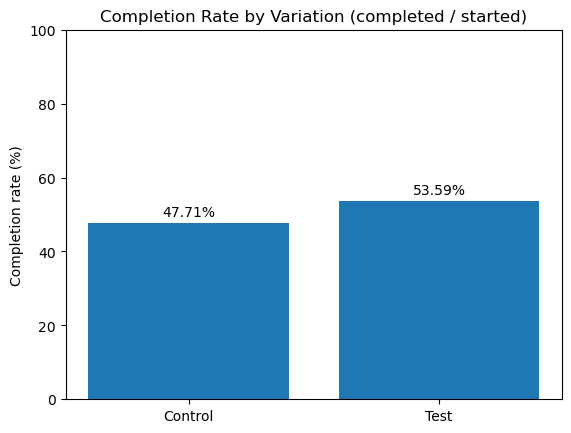

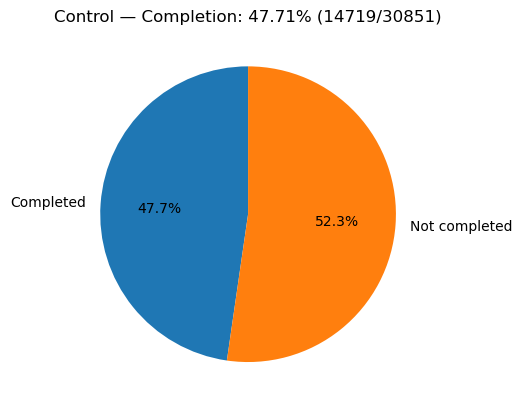

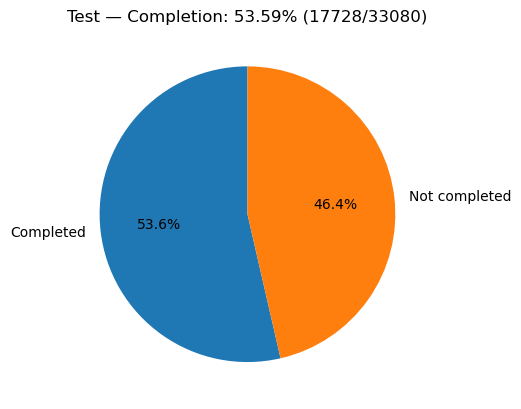

In [7]:
# === Completion rate table (Control vs Test) ===
# per_var already has: variation, current_started, completed, completion_rate
out = (
    per_var[["variation", "current_started", "completed", "completion_rate"]]
    .assign(completion_rate_pct=lambda d: (d["completion_rate"]*100).round(2))
    .sort_values("variation")
)
print(out.to_string(index=False))

# === Bar chart: completion rate (%) by variation ===
import matplotlib.pyplot as plt

plt.figure()
plt.bar(out["variation"], out["completion_rate_pct"])
for i, v in enumerate(out["completion_rate_pct"].tolist()):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center", va="bottom")
plt.ylim(0, 100)
plt.ylabel("Completion rate (%)")
plt.title("Completion Rate by Variation (completed / started)")
plt.show()

# === OPTIONAL: One pie per variation (Completed vs Not Completed) ===
for _, row in out.iterrows():
    var = row["variation"]
    comp = int(row["completed"])
    started = int(row["current_started"])
    not_comp = started - comp
    plt.figure()
    plt.pie([comp, not_comp],
            labels=["Completed", "Not completed"],
            autopct="%1.1f%%",
            startangle=90)
    plt.title(f"{var} — Completion: {row['completion_rate_pct']:.2f}% "
              f"({comp}/{started})")
    plt.show()

### Hypothesis Testing <a id="hypothesis-testing"></a>

[↑ Back to top](#top)

In [8]:
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

# ========================================
# 1. COMPLETION RATE TEST (z-test)
# ========================================


control_total = comparison_df.loc[comparison_df["variation"]=="Control", "started"].values[0]
control_completions = comparison_df.loc[comparison_df["variation"]=="Control", "completed"].values[0]

test_total = comparison_df.loc[comparison_df["variation"]=="Test", "started"].values[0]
test_completions = comparison_df.loc[comparison_df["variation"]=="Test", "completed"].values[0]

# Compute rates
p_control = control_completions / control_total
p_test = test_completions / test_total
diff = p_test - p_control

print("=== Completion Rates ===")
print(f"Control: {p_control:.3%} ({control_completions}/{control_total})")
print(f"Test: {p_test:.3%} ({test_completions}/{test_total})")
print(f"Difference: {diff:.3%}")

# Run z-test (one-tailed, H1: Test > Control)
counts = np.array([test_completions, control_completions])
nobs = np.array([test_total, control_total])
stat, pval = proportions_ztest(count=counts, nobs=nobs, alternative="larger")

print("\n=== Z-Test for Completion Rate ===")
print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {pval:.4f}")
print("Significant?" , "✅ Yes" if pval < 0.05 else "❌ No")

# ========================================
# 2. COST-EFFECTIVENESS THRESHOLD (≥ 5%)
# ========================================

threshold = 0.05
print("\n=== Cost-Effectiveness Check ===")

if diff >= threshold:
    msg = (
        f"Observed improvement {diff:.3%} meets/exceeds threshold of {threshold:.0%} ✅\n"
        "Statistically: The new design outperforms the old design (p < 0.05).\n"
        "Practically: The improvement is large enough (≥ 5%) to justify implementation costs.\n"
        "Business Decision: Vanguard should adopt the new design, as it delivers both statistical and economic value."
    )
else:
    msg = (
        f"Observed improvement {diff:.3%} does NOT meet threshold of {threshold:.0%} ❌\n"
        "Decision: Not cost-effective yet—iterate and re-test."
    )

print(msg)


=== Completion Rates ===
Control: 47.756% (14758/30903)
Test: 53.657% (17784/33144)
Difference: 5.901%

=== Z-Test for Completion Rate ===
Z-statistic: 14.9265
P-value: 0.0000
Significant? ✅ Yes

=== Cost-Effectiveness Check ===
Observed improvement 5.901% meets/exceeds threshold of 5% ✅
Statistically: The new design outperforms the old design (p < 0.05).
Practically: The improvement is large enough (≥ 5%) to justify implementation costs.
Business Decision: Vanguard should adopt the new design, as it delivers both statistical and economic value.


# 2. Time spent by steps <a id="time-spent-steps"></a>

In [9]:


# Format helper: seconds → MM:SS
def format_minutes_seconds(seconds):
    if pd.isna(seconds):
        return "-"
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes:02d}:{secs:02d}"


# Store results
results = []

for variation in ["Control", "Test"]:
    df_var = df_clean[df_clean["variation"] == variation]

    # Get first timestamp per step in each visit
    df_first = (
        df_var.sort_values(["visit_id", "process_step", "date_time"])
              .groupby(["visit_id", "process_step"], as_index=False)
              .first()
    )

    # Pivot to wide format
    df_wide = df_first.pivot(index="visit_id", columns="process_step", values="date_time")
    df_wide = df_wide.reindex(columns=required_steps)

    # For each transition, compute time only where both steps exist
    avg_row = {"variation": variation}
    for step_from, step_to in step_pairs:
        col = f"{step_from} → {step_to}"
        mask = df_wide[step_from].notna() & df_wide[step_to].notna()
        durations = df_wide.loc[mask, step_to] - df_wide.loc[mask, step_from]
        mean_seconds = durations.dt.total_seconds().mean()
        avg_row[col] = format_minutes_seconds(mean_seconds)

    results.append(avg_row)

# Final dataframe
avg_step_times = pd.DataFrame(results)

# Show result
pd.set_option("display.max_columns", None)
print(avg_step_times)

  variation start → step_1 step_1 → step_2 step_2 → step_3 step_3 → confirm
0   Control          01:03           00:50           01:49            02:48
1      Test          00:51           01:15           01:47            02:22


## 2.1 Time by steps - test <a id="time-by-steps-test"></a>

[↑ Back to top](#top)

In [10]:
from scipy.stats import ttest_ind, mannwhitneyu

# ---- 1) Build per-visit wide table once (all variations) ----
df_use = df_clean[df_clean["process_step"].isin(required_steps)].copy()
df_use["date_time"] = pd.to_datetime(df_use["date_time"], errors="coerce")

# earliest timestamp per step/visit
df_first_all = (
    df_use.sort_values(["visit_id", "process_step", "date_time"])
          .groupby(["visit_id", "process_step"], as_index=False).first()
)

wide = df_first_all.pivot(index="visit_id", columns="process_step", values="date_time")
wide = wide.reindex(columns=required_steps)

# variation per visit
visit_var = df_use[["visit_id","variation"]].drop_duplicates("visit_id")
wide = wide.merge(visit_var, on="visit_id", how="left")

# ---- 2) Helper: duration series for a step pair & variation ----
def durations_seconds(wide_df, step_from, step_to, variation):
    mask = (
        wide_df["variation"].eq(variation) &
        wide_df[step_from].notna() &
        wide_df[step_to].notna()
    )
    secs = (wide_df.loc[mask, step_to] - wide_df.loc[mask, step_from]).dt.total_seconds()
    # keep only positive/non-negative durations; drop weird negatives if any
    return secs.dropna()[secs >= 0]

# ---- 3) Hedges' g (unbiased Cohen's d) ----
def hedges_g(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    mx, my = x.mean(), y.mean()
    sx, sy = x.std(ddof=1), y.std(ddof=1)
    # pooled SD (unequal sizes)
    sp = np.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2)) if (nx+ny-2) > 0 else np.nan
    d = (mx - my) / sp if sp > 0 else np.nan
    # small-sample correction
    J = 1 - (3 / (4*(nx+ny) - 9)) if (nx+ny) > 2 else 1
    return d * J

# ---- 4) Benjamini–Hochberg FDR on a list of p-values ----
def fdr_bh(pvals):
    p = np.array(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    ranked = np.empty_like(order)
    ranked[order] = np.arange(1, m+1)
    q = p * m / ranked
    # enforce monotonicity
    q_sorted = np.minimum.accumulate(q[order][::-1])[::-1]
    q_adj = np.empty_like(q_sorted)
    q_adj[order] = q_sorted
    return np.clip(q_adj, 0, 1)

# ---- 5) Run tests per transition ----
rows = []
for step_from, step_to in step_pairs:
    # gather samples
    c = durations_seconds(wide, step_from, step_to, "Control")
    t = durations_seconds(wide, step_from, step_to, "Test")

    # basic stats
    n_c, n_t = len(c), len(t)
    mean_c, mean_t = c.mean(), t.mean()
    med_c, med_t = c.median(), t.median()
    sd_c, sd_t = c.std(ddof=1), t.std(ddof=1)

    # Welch's t-test (two-sided)
    t_stat, p_t = (np.nan, np.nan)
    if n_c > 1 and n_t > 1:
        t_stat, p_t = ttest_ind(c, t, equal_var=False, nan_policy="omit")

    # Mann–Whitney U (two-sided) — robust fallback
    p_u = np.nan
    if n_c > 0 and n_t > 0:
        try:
            _, p_u = mannwhitneyu(c, t, alternative="two-sided")
        except Exception:
            p_u = np.nan

    # Effect size (Hedges' g): positive means Control > Test in seconds
    g = hedges_g(c, t)

    rows.append({
        "transition": f"{step_from} → {step_to}",
        "n_control": n_c,
        "n_test": n_t,
        "mean_s_control": round(mean_c, 2) if pd.notna(mean_c) else np.nan,
        "mean_s_test": round(mean_t, 2) if pd.notna(mean_t) else np.nan,
        "median_s_control": round(med_c, 2) if pd.notna(med_c) else np.nan,
        "median_s_test": round(med_t, 2) if pd.notna(med_t) else np.nan,
        "std_s_control": round(sd_c, 2) if pd.notna(sd_c) else np.nan,
        "std_s_test": round(sd_t, 2) if pd.notna(sd_t) else np.nan,
        "t_stat": round(t_stat, 3) if pd.notna(t_stat) else np.nan,
        "p_welch": p_t,
        "p_mannwhitney": p_u,
        "hedges_g": round(g, 3) if pd.notna(g) else np.nan,
    })

tests_df = pd.DataFrame(rows)

# FDR adjust the Welch p-values
tests_df["q_fdr"] = fdr_bh(tests_df["p_welch"].fillna(1.0))

# Niceties: format seconds to MM:SS for the means/medians
def mmss(x):
    if pd.isna(x): return "-"
    m = int(x // 60); s = int(round(x % 60))
    return f"{m:02d}:{s:02d}"

for col in ["mean_s_control","mean_s_test","median_s_control","median_s_test"]:
    tests_df[col.replace("_s_", "_mmss_")] = tests_df[col].apply(mmss)

from tabulate import tabulate  # install if missing: pip install tabulate

# Shorten and format columns for readability
display_df = tests_df.copy()

# Round p-values and q-values
display_df["p_welch"] = display_df["p_welch"].apply(lambda x: f"{x:.3g}" if pd.notna(x) else "-")
display_df["q_fdr"] = display_df["q_fdr"].apply(lambda x: f"{x:.3g}" if pd.notna(x) else "-")
display_df["p_mannwhitney"] = display_df["p_mannwhitney"].apply(lambda x: f"{x:.3g}" if pd.notna(x) else "-")

# Significance marker
display_df["Sig"] = ["✅" if (q != "-" and float(str(q)) < 0.05) else "❌" for q in display_df["q_fdr"]]

# Select + rename columns for display
nice_cols = {
    "transition": "Transition",
    "n_control": "N_Ctrl",
    "n_test": "N_Test",
    "mean_mmss_control": "Mean Ctrl",
    "mean_mmss_test": "Mean Test",
    "median_mmss_control": "Median Ctrl",
    "median_mmss_test": "Median Test",
    "hedges_g": "g",
    "p_welch": "p Welch",
    "q_fdr": "q FDR",
    "Sig": "Signif"
}
table = display_df[list(nice_cols.keys())].rename(columns=nice_cols)

# Print as nice table
print("\n=== Completion Step-Time Tests (Control vs Test) ===")
print(tabulate(table, headers="keys", tablefmt="github", showindex=False))

print("\nLegend:")
print(" - Durations = MM:SS between steps")
print(" - g = Hedges’ g (effect size): >0 means Control slower, <0 means Test slower")
print(" - p Welch = Welch's t-test p-value (uncorrected)")
print(" - q FDR = Benjamini–Hochberg corrected p-value")
print(" - ✅ = significant at q<0.05")
print("""📊 Overall story

- Test is faster in early (start → step_1) and late (step_3 → confirm) transitions.
- Test is slower between step_1 → step_2.
- No difference between step_2 → step_3.
- Effects are statistically robust, though the effect sizes (g) are small in magnitude.
""")


=== Completion Step-Time Tests (Control vs Test) ===
| Transition       |   N_Ctrl |   N_Test | Mean Ctrl   | Mean Test   | Median Ctrl   | Median Test   |      g |   p Welch |    q FDR | Signif   |
|------------------|----------|----------|-------------|-------------|---------------|---------------|--------|-----------|----------|----------|
| start → step_1   |    23193 |    27861 | 01:05       | 00:52       | 00:22         | 00:12         |  0.046 |  8.34e-07 | 1.11e-06 | ✅       |
| step_1 → step_2  |    19951 |    24226 | 00:51       | 01:16       | 00:22         | 00:31         | -0.16  |  2e-66    | 8.01e-66 | ✅       |
| step_2 → step_3  |    17995 |    21823 | 01:50       | 01:48       | 01:19         | 01:13         |  0.014 |  0.15     | 0.15     | ❌       |
| step_3 → confirm |    15207 |    18268 | 02:49       | 02:23       | 01:30         | 00:58         |  0.089 |  4.53e-16 | 9.05e-16 | ✅       |

Legend:
 - Durations = MM:SS between steps
 - g = Hedges’ g (effect size)

# 3. Error Rate <a id="error-rate"></a>

In [11]:
# === 1. Sort per visit by time, detect step-backs ===
df_sorted = df[df["process_step"].isin(required_steps)].copy()
df_sorted["step_index"] = df_sorted["process_step"].map(step_order)
df_sorted = df_sorted.sort_values(["visit_id", "date_time"])
df_sorted["prev_step_index"] = df_sorted.groupby("visit_id")["step_index"].shift(1)
df_sorted["prev_step"] = df_sorted.groupby("visit_id")["process_step"].shift(1)
df_sorted["step_back"] = df_sorted["step_index"] < df_sorted["prev_step_index"]

# === 2. Filter to actual step-backs ===
df_stepbacks = df_sorted[df_sorted["step_back"] == True].copy()
df_stepbacks["transition"] = df_stepbacks["process_step"] + " ← " + df_stepbacks["prev_step"]

# === 3. Count of step-backs per variation (events) ===
stepback_counts = (
    df_stepbacks.groupby("variation", observed=True)
                .size()
                .reset_index(name="total_step_back_events")
)
print("=== Error per Variation (EVENTS) ===")
print(stepback_counts.to_string(index=False))

# === 4. Users with step-backs and averages ===
# Per error-user (users who have >=1 step-back)
per_user = (
    df_stepbacks.groupby(["variation", "visit_id"], observed=True)
                .size()
                .reset_index(name="step_backs_per_user")
)

users_with_sb = (
    per_user.groupby("variation", observed=True)
            .size()
            .reset_index(name="users_with_stepbacks")
)

avg_per_error_user = (
    per_user.groupby("variation", observed=True)["step_backs_per_user"]
            .mean()
            .round(2)
            .reset_index(name="avg_stepbacks_per_error_user")
)

# Total users (visits) per variation
total_users = (
    df_sorted.groupby("variation", observed=True)["visit_id"]
             .nunique()
             .reset_index(name="total_users")
)

# Merge everything + compute unconditional average and % users with step-backs
summary = (
    total_users
    .merge(users_with_sb, on="variation", how="left")
    .merge(stepback_counts, on="variation", how="left")
    .merge(avg_per_error_user, on="variation", how="left")
    .fillna({"users_with_stepbacks": 0, "total_step_back_events": 0, "avg_stepbacks_per_error_user": 0})
)

summary["avg_stepbacks_per_user_all"] = (
    summary["total_step_back_events"] / summary["total_users"]
).round(2)

summary["pct_users_with_stepbacks_%"] = (
    summary["users_with_stepbacks"] / summary["total_users"] * 100
).round(2)

# Tidy column order
summary = summary[[
    "variation",
    "total_users",
    "users_with_stepbacks",
    "pct_users_with_stepbacks_%",
    "total_step_back_events",
    "avg_stepbacks_per_error_user",  # conditional avg (only among users with >=1)
    "avg_stepbacks_per_user_all"     # unconditional avg (across ALL users)
]]

print("\n=== Error Users Summary (counts, %, and both averages) ===")
print(summary.to_string(index=False))


=== Error per Variation (EVENTS) ===
variation  total_step_back_events
  Control                    9695
     Test                   16337

=== Error Users Summary (counts, %, and both averages) ===
variation  total_users  users_with_stepbacks  pct_users_with_stepbacks_%  total_step_back_events  avg_stepbacks_per_error_user  avg_stepbacks_per_user_all
  Control        32181                  6602                       20.52                    9695                          1.47                        0.30
     Test        37122                 10036                       27.04                   16337                          1.63                        0.44


In [12]:
# Total users per variation
total_users = df_sorted.groupby("variation")["visit_id"].nunique().reset_index(name="total_users")

# Step-back events per variation
events = df_stepbacks.groupby("variation")["visit_id"].count().reset_index(name="total_stepback_events")

# Merge and compute unconditional average
avg_all = events.merge(total_users, on="variation")
avg_all["avg_stepbacks_per_user_all"] = (avg_all["total_stepback_events"] / avg_all["total_users"]).round(2)

print(avg_all)


  variation  total_stepback_events  total_users  avg_stepbacks_per_user_all
0   Control                   9695        32181                        0.30
1      Test                  16337        37122                        0.44


### 3.1 Summary of the Error count and % per step <a id="error-summary"></a>

[↑ Back to top](#top)

In [13]:

# === A) Transition matrix (To ← From) — overall counts ===
trans_matrix = (
    df_stepbacks.groupby(["process_step", "prev_step"], observed=True)
                .size()
                .unstack(fill_value=0)
    .reindex(index=required_steps, columns=required_steps, fill_value=0)
)

print("\n=== Step-Backs by Step (To ← From) — COUNTS ===")
print(trans_matrix.to_string())

# === B) Transition matrix as percentages ===
# 1) Column-normalized: share of where users went when stepping BACK FROM each step
col_sums = trans_matrix.sum(axis=0).replace(0, np.nan)
trans_pct_by_from = (trans_matrix.div(col_sums, axis=1) * 100).fillna(0).round(1)

print("\n=== Step-Backs (To ← From) — % of step-backs FROM each step (columns sum to 100%) ===")
print(trans_pct_by_from.to_string())

# 2) Row-normalized: share of sources for step-backs that ended at each destination step
row_sums = trans_matrix.sum(axis=1).replace(0, np.nan)
trans_pct_by_to = (trans_matrix.div(row_sums, axis=0) * 100).fillna(0).round(1)

print("\n=== Step-Backs (To ← From) — % of step-backs TO each step (rows sum to 100%) ===")
print(trans_pct_by_to.to_string())

# === C) Simple one-step summaries ===
to_counts   = df_stepbacks["process_step"].value_counts().reindex(required_steps, fill_value=0)
from_counts = df_stepbacks["prev_step"].value_counts().reindex(required_steps, fill_value=0)

print("\n=== Step-Backs — DESTINATION step (how many step-backs landed on each step) ===")
print(to_counts.to_string())

print("\n=== Step-Backs — SOURCE step (how many step-backs originated from each step) ===")
print(from_counts.to_string())

# === D) Breakdown by variation (counts + % by FROM step) ===
for var in ["Control", "Test"]:
    dfv = df_stepbacks[df_stepbacks["variation"] == var]
    mat = (
        dfv.groupby(["process_step", "prev_step"], observed=True)
           .size().unstack(fill_value=0)
        .reindex(index=required_steps, columns=required_steps, fill_value=0)
    )
    print(f"\n=== [{var}] Step-Backs (To ← From) — COUNTS ===")
    print(mat.to_string())

    col_sums_v = mat.sum(axis=0).replace(0, np.nan)
    pct_by_from_v = (mat.div(col_sums_v, axis=1) * 100).fillna(0).round(1)
    print(f"\n=== [{var}] Step-Backs (To ← From) — % FROM each step (cols sum to 100%) ===")
    print(pct_by_from_v.to_string())

# === E) (Optional) Sorted list of transitions for quick reading ===
trans_counts_overall = (
    df_stepbacks["transition"].value_counts()
)
print("\n=== Step-Back Transitions (string form) — Overall counts, sorted ===")
print(trans_counts_overall.to_string())

trans_counts_by_var = (
    df_stepbacks.groupby("variation")["transition"]
                .value_counts()
                .unstack(fill_value=0)
                .reindex(index=["Control", "Test"], fill_value=0)
)
print("\n=== Step-Back Transitions — Counts by Variation ===")
print(trans_counts_by_var.to_string())


=== Step-Backs by Step (To ← From) — COUNTS ===
prev_step     start  step_1  step_2  step_3  confirm
process_step                                        
start             0    8900    2417    3302      927
step_1            0       0    4531    1041      144
step_2            0       0       0    4646        1
step_3            0       0       0       0      123
confirm           0       0       0       0        0

=== Step-Backs (To ← From) — % of step-backs FROM each step (columns sum to 100%) ===
prev_step     start  step_1  step_2  step_3  confirm
process_step                                        
start           0.0   100.0    34.8    36.7     77.6
step_1          0.0     0.0    65.2    11.6     12.1
step_2          0.0     0.0     0.0    51.7      0.1
step_3          0.0     0.0     0.0     0.0     10.3
confirm         0.0     0.0     0.0     0.0      0.0

=== Step-Backs (To ← From) — % of step-backs TO each step (rows sum to 100%) ===
prev_step     start  step_1  step_2  ste

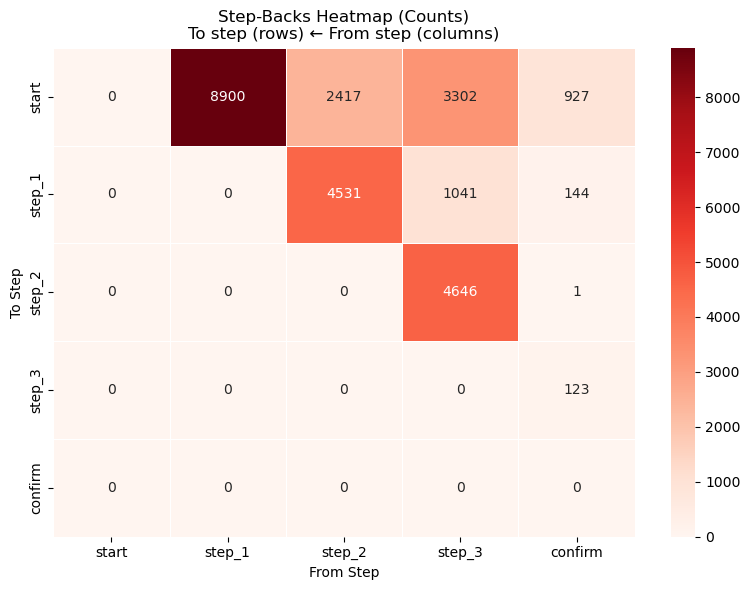

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# === Build transition matrix (To ← From) ===
trans_matrix = (
    df_stepbacks.groupby(["process_step", "prev_step"], observed=True)
                .size()
                .unstack(fill_value=0)
    .reindex(index=required_steps, columns=required_steps, fill_value=0)
)

# === Plot heatmap ===
plt.figure(figsize=(8, 6))
sns.heatmap(trans_matrix, annot=True, fmt="d", cmap="Reds", linewidths=0.5,
            xticklabels=trans_matrix.columns, yticklabels=trans_matrix.index)

plt.title("Step-Backs Heatmap (Counts)\nTo step (rows) ← From step (columns)")
plt.xlabel("From Step")
plt.ylabel("To Step")
plt.tight_layout()
plt.show()


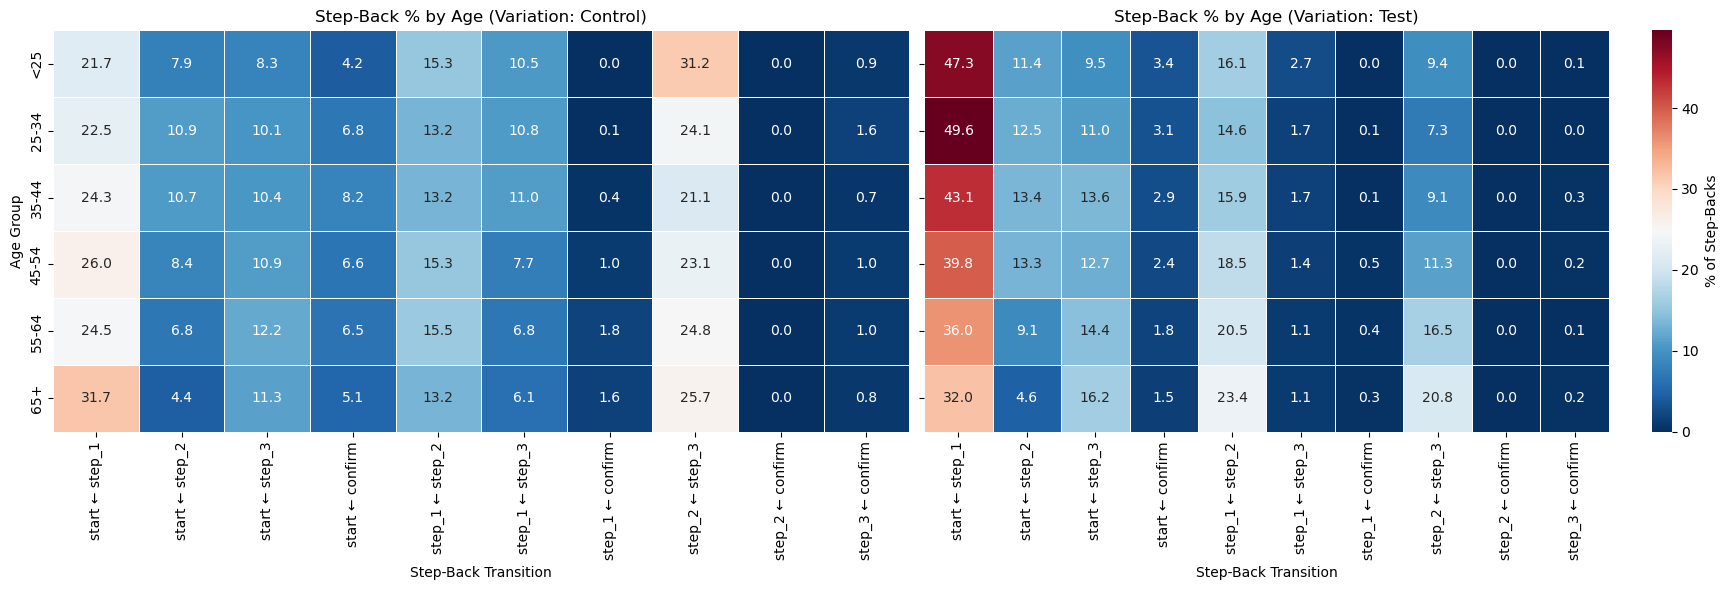

In [15]:
# 0) Ensure age_group from clnt_age
bins   = [-np.inf, 24, 34, 44, 54, 64, np.inf]   # 7 edges
labels = ['<25','25-34','35-44','45-54','55-64','65+']

df_sorted["age_group"] = pd.cut(
    df_sorted["clnt_age"].astype(float), bins=bins, labels=labels, right=True
)

# bring age_group into df_stepbacks (one per visit_id)
df_stepbacks = df_stepbacks.merge(
    df_sorted[["visit_id", "age_group"]].drop_duplicates(),
    on="visit_id", how="left"
)
df_stepbacks["age_group"] = pd.Categorical(df_stepbacks["age_group"], categories=labels, ordered=True)

# 1) Build ordered transitions (To ← From) — true step-backs only
columns_order = [
    f"{to} ← {frm}"
    for i, to in enumerate(required_steps)
    for j, frm in enumerate(required_steps)
    if j > i
]

# helper to get counts + row % for a variation
def stepback_tables_for_variation(df_var):
    counts = (
        df_var.groupby(["age_group", "transition"], observed=True)
              .size().unstack(fill_value=0)
              .reindex(columns=columns_order, fill_value=0)
              .sort_index()
    )
    pct = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
    return counts, pct.round(1)

# 2) Compute for both variations to share color scale
counts_ctrl, pct_ctrl = stepback_tables_for_variation(df_stepbacks[df_stepbacks["variation"]=="Control"])
counts_test, pct_test = stepback_tables_for_variation(df_stepbacks[df_stepbacks["variation"]=="Test"])
global_vmax = max(
    pct_ctrl.to_numpy().max() if not pct_ctrl.empty else 0,
    pct_test.to_numpy().max() if not pct_test.empty else 0
)

# 3) Plot side-by-side heatmaps (row-normalized %)
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.heatmap(pct_ctrl, annot=True, fmt=".1f", cmap="RdBu_r", linewidths=0.5,
            vmin=0, vmax=global_vmax, cbar=False, ax=axes[0])
axes[0].set_title("Step-Back % by Age (Variation: Control)")
axes[0].set_xlabel("Step-Back Transition")
axes[0].set_ylabel("Age Group")

sns.heatmap(pct_test, annot=True, fmt=".1f", cmap="RdBu_r", linewidths=0.5,
            vmin=0, vmax=global_vmax, cbar=True, ax=axes[1],
            cbar_kws={"label": "% of Step-Backs"})
axes[1].set_title("Step-Back % by Age (Variation: Test)")
axes[1].set_xlabel("Step-Back Transition")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

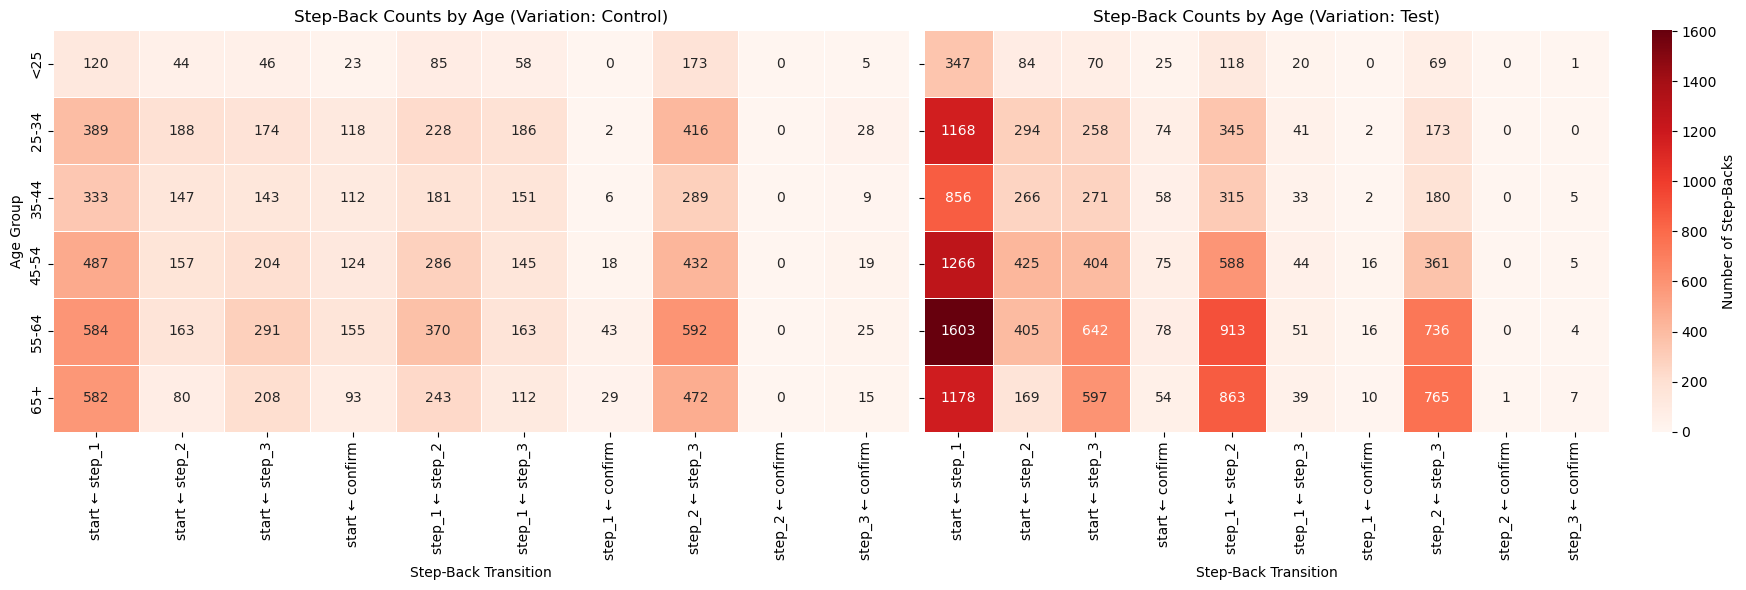

In [16]:
# helper: counts table only
def stepback_counts_for_variation(df_var):
    counts = (
        df_var.groupby(["age_group", "transition"], observed=True)
              .size().unstack(fill_value=0)
              .reindex(columns=columns_order, fill_value=0)
              .sort_index()
    )
    return counts

# compute counts for both variations
counts_ctrl = stepback_counts_for_variation(df_stepbacks[df_stepbacks["variation"]=="Control"])
counts_test = stepback_counts_for_variation(df_stepbacks[df_stepbacks["variation"]=="Test"])

# shared vmax so colors are comparable
global_vmax = max(
    counts_ctrl.to_numpy().max() if not counts_ctrl.empty else 0,
    counts_test.to_numpy().max() if not counts_test.empty else 0
)

# plot counts heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.heatmap(counts_ctrl, annot=True, fmt="d", cmap="Reds", linewidths=0.5,
            vmin=0, vmax=global_vmax, cbar=False, ax=axes[0])
axes[0].set_title("Step-Back Counts by Age (Variation: Control)")
axes[0].set_xlabel("Step-Back Transition")
axes[0].set_ylabel("Age Group")

sns.heatmap(counts_test, annot=True, fmt="d", cmap="Reds", linewidths=0.5,
            vmin=0, vmax=global_vmax, cbar=True, ax=axes[1],
            cbar_kws={"label": "Number of Step-Backs"})
axes[1].set_title("Step-Back Counts by Age (Variation: Test)")
axes[1].set_xlabel("Step-Back Transition")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


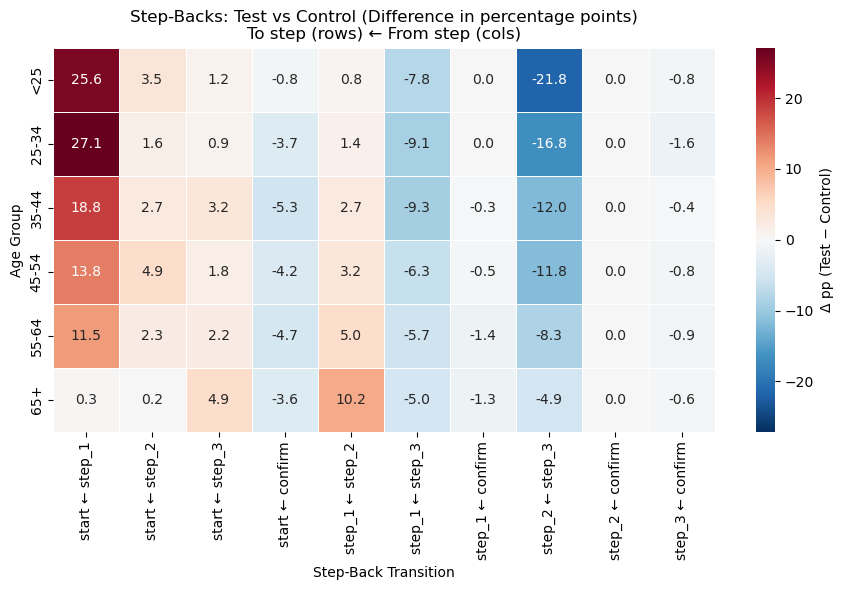

✅ Overall story
- Young Test users (<35): much more likely to restart (start ← step_1) compared to Control.
- Older Test users (65+): more likely to backtrack one step (step_1 ← step_2).
- Control users (all ages): more likely to move backward late in the funnel (step_2 ← step_3).
- Some transitions (like falling back after confirm) don’t differ much.


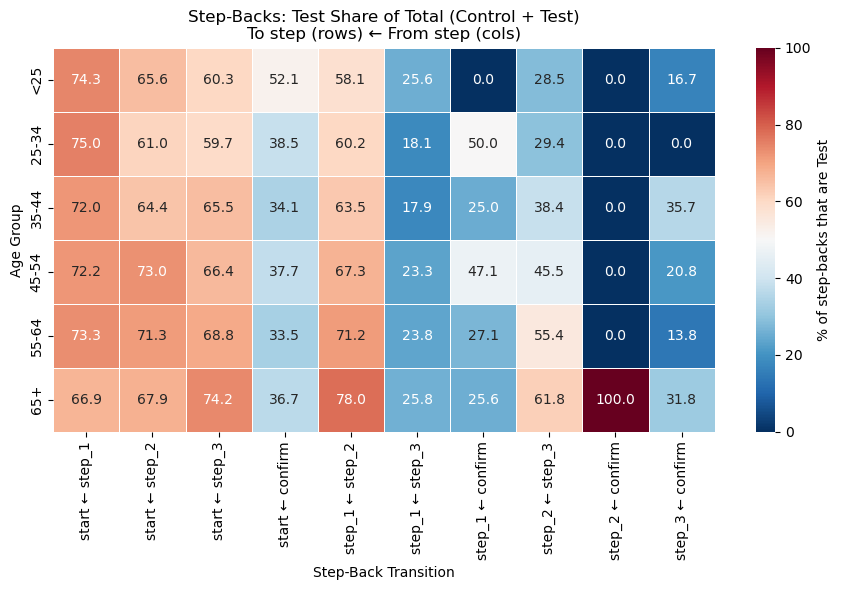

✅ Overall story
-Test users generate most step-backs at the start of the funnel (restarts from step_1 or step_2).
-Control users dominate step-backs later in the funnel (especially step_2 ← step_3 and undoing confirm).
-This complements the previous Δpp heatmap: Test vs Control have different patterns (relative shares) and also different absolute volumes depending on where the backtracking happens.


In [17]:


# === 3A) Difference heatmap: Test% - Control% (percentage points) ===
# align (just in case)
pct_ctrl = pct_ctrl.reindex_like(pct_test).fillna(0)
diff_pp = (pct_test - pct_ctrl).round(1)  # percentage-point difference

# symmetric color scale around 0
absmax = float(np.nanmax(np.abs(diff_pp.to_numpy()))) if not diff_pp.empty else 0

plt.figure(figsize=(9, 6))
sns.heatmap(
    diff_pp, annot=True, fmt=".1f", cmap="RdBu_r", linewidths=0.5,
    vmin=-absmax, vmax=absmax, cbar_kws={"label": "Δ pp (Test − Control)"}
)
plt.title("Step-Backs: Test vs Control (Difference in percentage points)\nTo step (rows) ← From step (cols)")
plt.xlabel("Step-Back Transition")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()
print("✅ Overall story\n"
      "- Young Test users (<35): much more likely to restart (start ← step_1) compared to Control.\n"
      "- Older Test users (65+): more likely to backtrack one step (step_1 ← step_2).\n"
      "- Control users (all ages): more likely to move backward late in the funnel (step_2 ← step_3).\n"
      "- Some transitions (like falling back after confirm) don’t differ much.")


# === 3B) Pooled share heatmap: share of Test among both variations (%) ===
# Use counts (not row-normalized) so volume is considered
counts_ctrl = counts_ctrl.reindex_like(counts_test).fillna(0)
pooled = counts_ctrl + counts_test

with np.errstate(divide="ignore", invalid="ignore"):
    test_share = (counts_test / pooled * 100).replace([np.inf, -np.inf], np.nan).fillna(0).round(1)

vmax_share = 100.0  # 0–100%
plt.figure(figsize=(9, 6))
sns.heatmap(
    test_share, annot=True, fmt=".1f", cmap="RdBu_r", linewidths=0.5,
    vmin=0, vmax=vmax_share, cbar_kws={"label": "% of step-backs that are Test"}
)
plt.title("Step-Backs: Test Share of Total (Control + Test)\nTo step (rows) ← From step (cols)")
plt.xlabel("Step-Back Transition")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()
print("✅ Overall story\n"
      "-Test users generate most step-backs at the start of the funnel (restarts from step_1 or step_2).\n"
      "-Control users dominate step-backs later in the funnel (especially step_2 ← step_3 and undoing confirm).\n"
      "-This complements the previous Δpp heatmap: Test vs Control have different patterns (relative shares) "
      "and also different absolute volumes depending on where the backtracking happens.")
